# Module 2 – Machine Learning Workflow
Dataset – hotel_bookings.csv
This notebook demonstrates the complete Machine Learning workflow using the Hotel Bookings dataset.
The goal is to understand each step from defining the problem to deploying the final model.

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/hotel_bookings.csv")

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Problem Definition

Problem Definition is the first step of a Machine Learning project. It means clearly defining the problem that the model needs to solve.

For this project, the problem is:

**Can we predict whether a hotel booking will be cancelled based on the available booking information?**

Target variable:

`is_canceled`

Problem type:

**Binary Classification**

In [2]:
print("Target Variable: is_canceled")
print("Problem Type: Binary Classification")

df["is_canceled"].value_counts()

Target Variable: is_canceled
Problem Type: Binary Classification


is_canceled
0    75166
1    44224
Name: count, dtype: int64

## 2. Business Understanding

Business Understanding connects the Machine Learning problem with a real-world business objective.

For a hotel, predicting booking cancellations can help with:

- Better reservation planning
- Room availability management
- Understanding cancellation patterns
- Improving business decisions

The goal is to identify bookings that may be cancelled and support better hotel planning.

In [3]:
print("Business Objective:")
print("Predict hotel booking cancellations to support better reservation planning.")

Business Objective:
Predict hotel booking cancellations to support better reservation planning.


## 3. Data Collection

Data Collection means gathering the data required to solve the Machine Learning problem.

For this project, we use the Hotel Bookings dataset:

`data/hotel_bookings.csv`

The dataset contains information such as:

- Hotel
- Lead time
- Arrival details
- Number of guests
- Room type
- Previous cancellations
- ADR
- Special requests
- Booking information

In [4]:
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully.
Rows: 119390
Columns: 32


## 4. Data Understanding

Data Understanding means examining the structure and quality of the dataset before building a model.

We check:

- Number of rows and columns
- Data types
- Missing values
- Numerical features
- Categorical features
- Target variable

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (119390, 32)


In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

## 5. EDA – Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand patterns, distributions and relationships in the dataset.

We will first examine the distribution of the target variable.

In [8]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

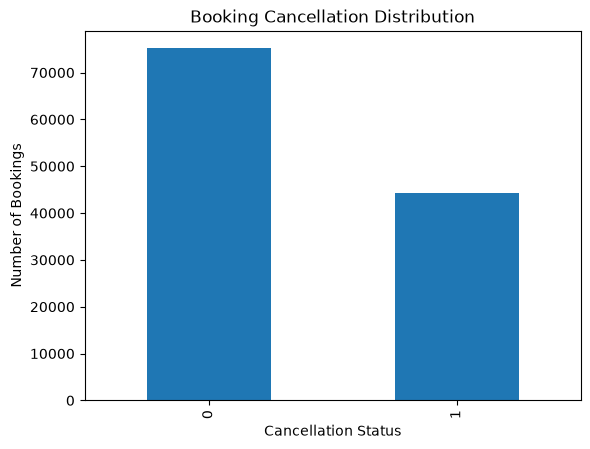

In [9]:
import matplotlib.pyplot as plt

df["is_canceled"].value_counts().plot(kind="bar")

plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.title("Booking Cancellation Distribution")
plt.show()

The target variable contains two classes:

- `0` – Booking was not cancelled
- `1` – Booking was cancelled

Checking the target distribution helps us understand whether the classes are balanced or imbalanced.

## 6. Data Preprocessing

Data Preprocessing prepares the raw data for Machine Learning.

Common preprocessing steps include:

- Handling missing values
- Removing invalid values
- Encoding categorical variables
- Selecting useful features
- Scaling numerical features when required

Columns containing information that becomes available after the booking outcome should be avoided because they can cause data leakage.

In [4]:
df["children"] = df["children"].fillna(0)

print("Missing values in children:", df["children"].isnull().sum())

Missing values in children: 0


## 7. Feature Engineering

Feature Engineering means creating new and useful features from existing data.

We can create the total number of guests from adults, children and babies.

In [5]:
df["total_guests"] = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

df[["adults", "children", "babies", "total_guests"]].head()

,adults,children,babies,total_guests
0,2,0.0,0,2.0
1,2,0.0,0,2.0
2,1,0.0,0,1.0
3,1,0.0,0,1.0
4,2,0.0,0,2.0


We can also create the total number of nights stayed by combining weekend and weekday nights.

In [6]:
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df[
    [
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "total_stay_nights"
    ]
].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay_nights
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


## 8. Train/Test Split

Train/Test Split divides the dataset into two parts:

- **Training Set** – Used to train the model.
- **Testing Set** – Used to evaluate the model on unseen data.

The test data should not be used during model training.

For classification, stratification helps maintain a similar target-class distribution in both datasets.

In [7]:
from sklearn.model_selection import train_test_split

features = [
    "lead_time",
    "adults",
    "children",
    "babies",
    "total_stay_nights",
    "adr",
    "total_of_special_requests"
]

X = df[features]
y = df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (95512, 7)
Testing data: (23878, 7)


## 9. Model Selection

Since `is_canceled` is a binary classification target, classification algorithms can be used.

Some suitable algorithms are:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- Support Vector Machine

For this workflow, Logistic Regression is used as a simple baseline classification model.

In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print(model)

LogisticRegression(max_iter=1000)


## 10. Model Training

Model Training is the process of allowing the model to learn patterns from the training data.

The model learns the relationship between the input features and the target variable.

In [9]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 11. Prediction

After training, the model can make predictions on unseen test data.

The prediction represents whether the booking is expected to be cancelled.

`0` → Not Cancelled

`1` → Cancelled

In [10]:
predictions = model.predict(X_test)

predictions[:10]

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

## 12. Evaluation

Evaluation measures how well the model performs on unseen data.

For classification, commonly used metrics include:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC

Different metrics provide different information about model performance.

In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.695786916827205


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.71      0.86      0.78     15033
           1       0.64      0.41      0.50      8845

    accuracy                           0.70     23878
   macro avg       0.68      0.64      0.64     23878
weighted avg       0.69      0.70      0.68     23878



In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10}
Best CV Score: 0.49313285372480875


## 14. Model Selection – Final

After evaluating the model and tuning its hyperparameters, the final model can be selected.

The decision should consider:

- Evaluation metrics
- Model complexity
- Training time
- Interpretability
- Business requirements

The selected model should perform well on unseen data and be suitable for the intended business use.

In [14]:
final_model = grid.best_estimator_

final_predictions = final_model.predict(X_test)

print("Final Model:")
print(final_model)

Final Model:
LogisticRegression(C=10, max_iter=1000)


## 15. Deployment

Deployment means making the trained model available for real-world use.

The trained model can be saved and loaded later without training it again.

In [15]:
import joblib

joblib.dump(final_model, "hotel_booking_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [16]:
loaded_model = joblib.load("hotel_booking_model.pkl")

print("Model loaded successfully.")

Model loaded successfully.
